In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.tsa.ar_model import AutoReg

def find_repo_root(marker: str = "requirements.txt") -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / marker).exists():
            return candidate
    raise FileNotFoundError(f"Could not locate repo root (no {marker} found above {Path.cwd()})")

RESULTS_DIR = find_repo_root() / "data" / "results"

# Change this to graph a different model's result file.
RESULT_FILE = "test_har_log_rv.parquet"

df = pd.read_parquet(RESULTS_DIR / RESULT_FILE)
df["timestamp"] = pd.to_datetime(df["timestamp"])
predicted_col = next(c for c in df.columns if c.startswith("predicted_"))
actual_col = next(c for c in df.columns if c.startswith("actual_"))
df = df.rename(columns={predicted_col: "predicted", actual_col: "actual"}).set_index("timestamp").sort_index()
df.head()

,predicted,actual,MSE
timestamp,,,
2016-06-27,-9.384777,-8.750328,0.402525
2016-06-28,-9.521108,-8.932010,0.347037
2016-06-29,-9.499566,-9.419795,0.006363
2016-06-30,-9.586224,-9.811617,0.050802
2016-07-01,-9.736969,-10.514395,0.604391


## AR(1) benchmark

Fit directly on the `actual` series so it's a naive baseline: how well would a plain AR(1)
have done, compared to the HAR model's own prediction?

In [2]:
ar_model = AutoReg(df["actual"], lags=1, old_names=False).fit()
df["ar1"] = ar_model.fittedvalues.reindex(df.index)
df.head()

c:\Users\sarwa\backScratch\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,predicted,actual,MSE,ar1
timestamp,,,,
2016-06-27,-9.384777,-8.750328,0.402525,NaN
2016-06-28,-9.521108,-8.932010,0.347037,-9.219197
2016-06-29,-9.499566,-9.419795,0.006363,-9.351163
2016-06-30,-9.586224,-9.811617,0.050802,-9.705471
2016-07-01,-9.736969,-10.514395,0.604391,-9.990075


## Predicted vs. actual vs. AR(1)

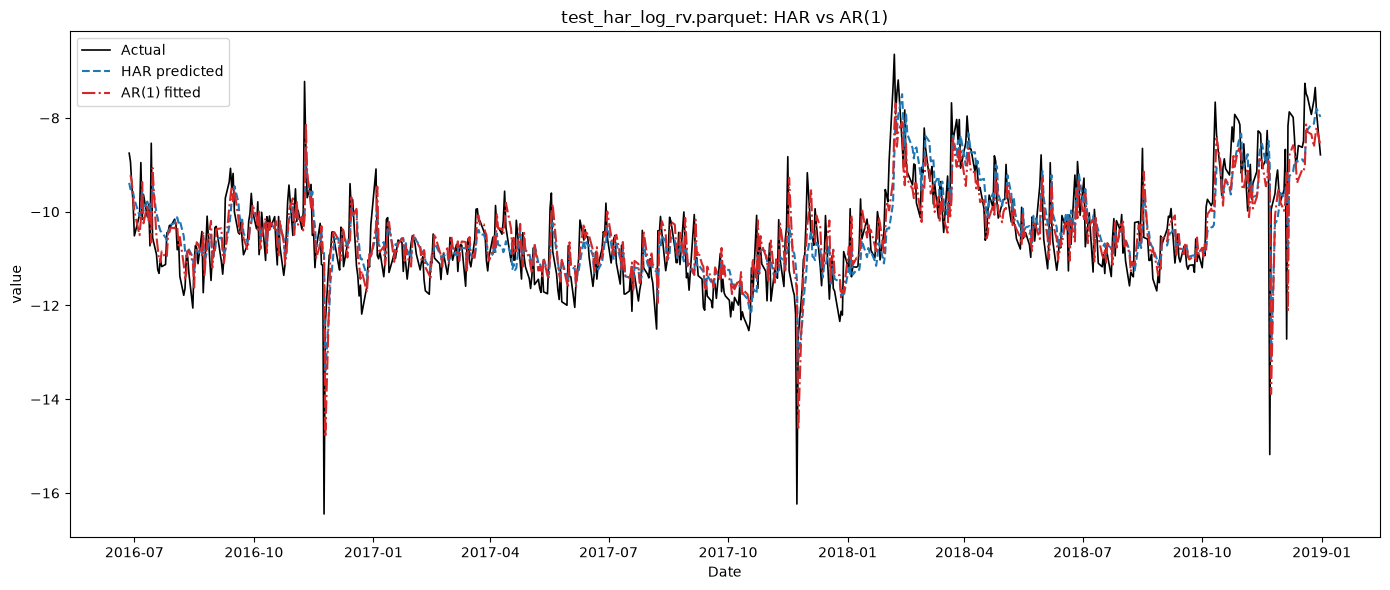

In [3]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df.index, df["actual"], label="Actual", color="black", linewidth=1.2)
ax.plot(df.index, df["predicted"], label="HAR predicted", color="tab:blue", linestyle="--")
ax.plot(df.index, df["ar1"], label="AR(1) fitted", color="tab:red", linestyle="-.")

ax.set_xlabel("Date")
ax.set_ylabel("value")
ax.set_title(f"{RESULT_FILE}: HAR vs AR(1)")
ax.legend()
plt.tight_layout()
plt.show()

## QLIKE

`QLIKE = actual/predicted - log(actual/predicted) - 1`, computed on the raw (exponentiated)
variance scale since the saved `actual`/`predicted` columns are log values. Lower is better,
and a perfect forecast gives exactly 0.

In [4]:
def qlike(actual_log, predicted_log):
    actual = np.exp(actual_log)
    predicted = np.exp(predicted_log)
    ratio = actual / predicted
    return ratio - np.log(ratio) - 1

df["qlike_har"] = qlike(df["actual"], df["predicted"])
df["qlike_ar1"] = qlike(df["actual"], df["ar1"])

summary = pd.DataFrame({
    "HAR": [df["qlike_har"].mean()],
    "AR(1)": [df["qlike_ar1"].mean()],
}, index=["mean QLIKE"])
summary

,HAR,AR(1)
mean QLIKE,0.344544,0.430783


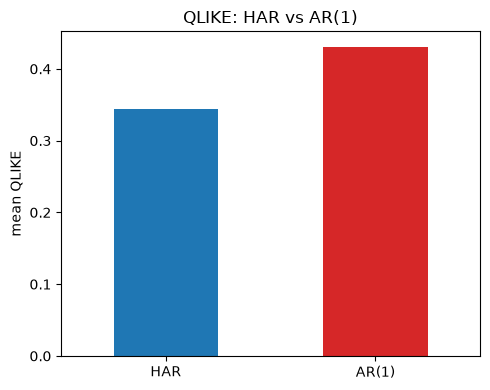

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
summary.loc["mean QLIKE"].plot(kind="bar", ax=ax, color=["tab:blue", "tab:red"])
ax.set_ylabel("mean QLIKE")
ax.set_title("QLIKE: HAR vs AR(1)")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()